In [6]:
%matplotlib inline

In [7]:
import streamlit as st

st.set_page_config(
    page_title="RetailPulse",
    layout="wide"
)

st.title("RetailPulse Dashboard")

st.markdown("""
### Features
- Demand Forecasting
- Customer Segmentation
- Churn Prediction
- Inventory Optimization
- Reports
""")

2026-06-20 11:09:26.016 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 11:09:26.017 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 11:09:26.017 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 11:09:26.018 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 11:09:26.019 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 11:09:26.021 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 11:09:26.022 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [8]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\aryan\ML PROJECT(ZIDIO)\mlruns\1\36ab8bb35db04c2b9d811dbf69583f4d\artifacts\cleaned_retail.csv"
)

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

daily_sales = (
    df.groupby("InvoiceDate")["Sales"]
      .sum()
      .reset_index()
)

print(daily_sales.head())

          InvoiceDate    Sales
0 2009-12-01 07:45:00   505.30
1 2009-12-01 07:46:00   145.80
2 2009-12-01 09:06:00   630.33
3 2009-12-01 09:08:00   310.75
4 2009-12-01 09:24:00  2286.24


In [9]:
growth = st.slider(
    "Expected Demand Growth (%)",
    -20,
    50,
    10
)

future_sales = (
    daily_sales["Sales"].iloc[-1]
    * (1 + growth/100)
)

st.metric(
    "Projected Demand",
    round(future_sales,2)
)

2026-06-20 11:09:27.143 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 11:09:27.143 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 11:09:27.145 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 11:09:27.146 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 11:09:27.148 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 11:09:27.149 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 11:09:27.149 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-20 11:09:27.152 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

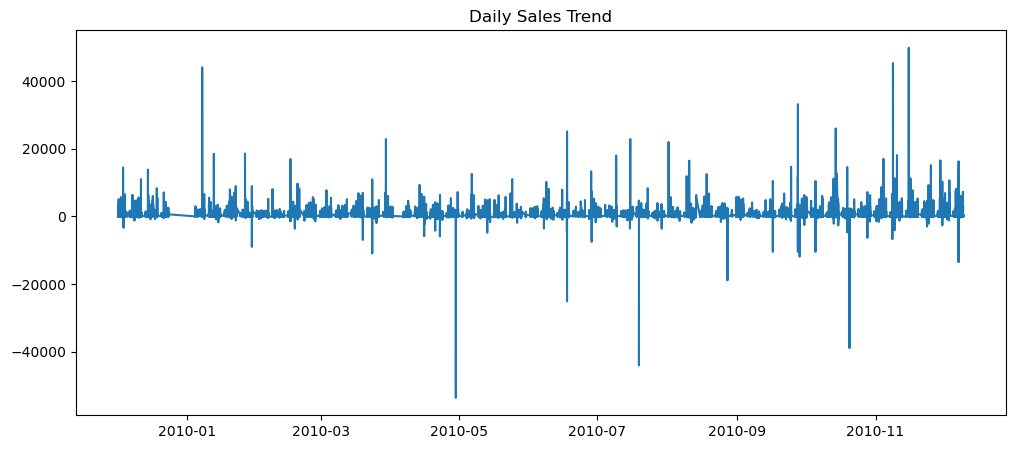

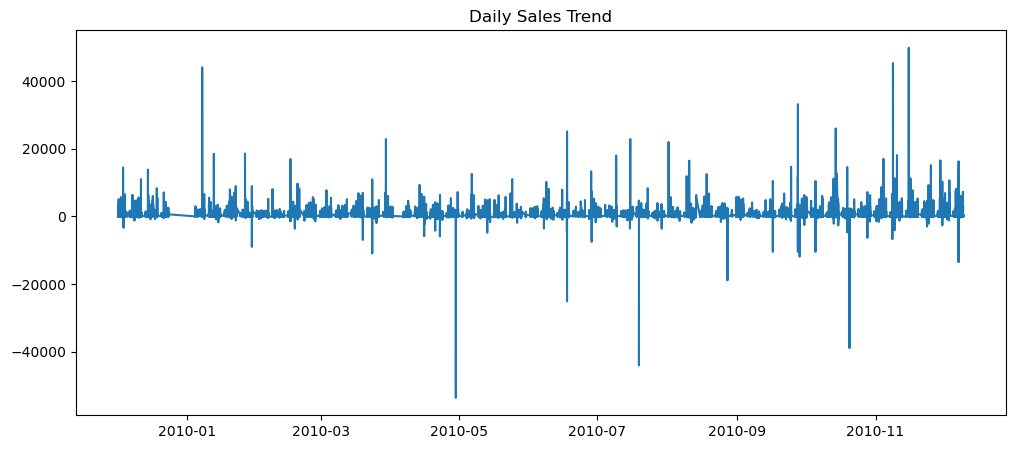

Projected Demand: 330.7

===== CUSTOMER SEGMENTATION =====
   Customer ID  Recency  Frequency  Monetary  KMeansCluster  DBSCANCluster
0      12346.0       67         15    -51.74              0              0
1      12347.0        3          2   1323.32              0              0
2      12348.0       74          1    222.16              0              0
3      12349.0       43          4   2646.99              0              0
4      12351.0       11          1    300.93              0              0
High Risk Customers: 1458

===== INVENTORY =====
Average Daily Demand: 375.78
Safety Stock: 1219.24
Reorder Point: 3849.71

===== KPI DASHBOARD =====
Revenue: 9505775.56
Customers: 4384
ALERT: Reorder Inventory

Reports Exported Successfully

===== WEEK 3 STATUS =====
                   Module Status
0             Forecasting   Done
1      Customer Analytics   Done
2  Inventory Optimization   Done
3           KPIs & Alerts   Done
4              CSV Export   Done


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================
# LOAD DATA
# =====================

df = pd.read_csv(
    r"C:\Users\aryan\ML PROJECT(ZIDIO)\mlruns\1\36ab8bb35db04c2b9d811dbf69583f4d\artifacts\cleaned_retail.csv"
)

rfm = pd.read_csv(
    r"C:\Users\aryan\ML PROJECT(ZIDIO)\mlruns\1\36ab8bb35db04c2b9d811dbf69583f4d\artifacts\rfm_customers.csv"
)

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# =====================
# DAY 16 FORECASTING
# =====================

daily_sales = (
    df.groupby("InvoiceDate")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,5))
plt.plot(
    daily_sales["InvoiceDate"],
    daily_sales["Sales"]
)
plt.title("Daily Sales Trend")
plt.show()

growth = 10

future_sales = (
    daily_sales["Sales"].iloc[-1]
    * (1 + growth/100)
)

print("Projected Demand:", round(future_sales,2))

# =====================
# DAY 17 CUSTOMER SEGMENTATION
# =====================

print("\n===== CUSTOMER SEGMENTATION =====")

print(rfm.head())

if "Recency" in rfm.columns:

    rfm["ChurnRisk"] = (
        rfm["Recency"] > 90
    ).astype(int)

    print(
        "High Risk Customers:",
        rfm["ChurnRisk"].sum()
    )

# =====================
# DAY 18 INVENTORY
# =====================

avg_daily_demand = (
    daily_sales["Sales"].mean()
)

lead_time = 7

safety_stock = (
    daily_sales["Sales"].std()
)

rop = (
    avg_daily_demand
    * lead_time
    + safety_stock
)

print("\n===== INVENTORY =====")
print("Average Daily Demand:", round(avg_daily_demand,2))
print("Safety Stock:", round(safety_stock,2))
print("Reorder Point:", round(rop,2))

# =====================
# DAY 19 KPI ALERTS
# =====================

total_revenue = df["Sales"].sum()

print("\n===== KPI DASHBOARD =====")

print(
    "Revenue:",
    round(total_revenue,2)
)

print(
    "Customers:",
    rfm.shape[0]
)

if rop > 1000:
    print("ALERT: Reorder Inventory")

# =====================
# DAY 20 EXPORTS
# =====================

rfm.to_csv(
    "customer_report.csv",
    index=False
)

daily_sales.to_csv(
    "sales_report.csv",
    index=False
)

print(
    "\nReports Exported Successfully"
)

# =====================
# DAY 21 SUMMARY
# =====================

summary = pd.DataFrame({

    "Module":[
        "Forecasting",
        "Customer Analytics",
        "Inventory Optimization",
        "KPIs & Alerts",
        "CSV Export"
    ],

    "Status":[
        "Done",
        "Done",
        "Done",
        "Done",
        "Done"
    ]
})

print("\n===== WEEK 3 STATUS =====")
print(summary)